In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/kaggle/input/datasets/sourav2083/class-dataset-movies/movie_prediction_dataset_final.csv')

In [3]:
df

,release_year,budget,runtime,is_sequel,director_name,director_popularity,lead_actor1,lead_actor1_popularity,primary_genre,genre2,studio_1,studio_2,brand_name,mpaa_rating,release_month,is_holiday_release,Distributor,First_Week_Income
0,2009,40000000,111,0,Mira Nair,1.3916,Hilary Swank,2.2810,Adventure,Drama,AE Electra Productions,Fox Searchlight Pictures,General,PG,10,0,Fox Searchlight Pictures,5305832.0
1,2009,237000000,162,1,James Cameron,4.3403,Sam Worthington,4.0107,Action,Adventure,Dune Entertainment,Lightstorm Entertainment,Avatar,PG-13,12,1,Twentieth Century Fox,137094051.0
2,2009,60000000,100,0,Henry Selick,1.6349,Dakota Fanning,7.9341,Animation,Family,LAIKA,Pandemonium,General,PG,2,0,Focus Features,20235921.0
3,2009,175000000,96,0,Pete Docter,1.3480,Ed Asner,1.4701,Animation,Comedy,Pixar,NaN,General,PG,5,0,Walt Disney Studios Motion Pictures,93072435.0
4,2009,70000000,153,0,Quentin Tarantino,3.8346,Brad Pitt,9.0310,Drama,Thriller,Universal Pictures,The Weinstein Company,General,R,8,0,The Weinstein Company,53703427.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3585,2025,23800000,93,0,Alex Parkinson,0.0618,Woody Harrelson,6.0845,Thriller,Drama,Dark Castle Entertainment,MetFilm Production,General,PG-13,2,0,Focus Features,10456885.0
3586,2025,9000000,107,0,Tony Tost,0.1493,Sydney Sweeney,21.2483,Crime,Thriller,Bron Studios,Creative Wealth Media Finance,General,R,8,0,NaN,NaN
3587,2025,8500000,118,0,Jon Avnet,0.3870,Neal McDonough,4.5676,Drama,NaN,Angel Studios,Unity Productions Foundation,General,PG,5,0,Angel,8607185.0
3588,2025,13000000,105,0,Johnny Martin,0.3193,Josh Duhamel,2.9623,Action,Thriller,Buffalo 8,Iervolino & Lady Bacardi Entertainment,General,R,6,0,NaN,NaN


In [41]:
import matplotlib.pyplot as plt

In [66]:
plt.style.use('seaborn-v0_8-whitegrid') 

In [5]:
yearly_income = df.groupby('release_year')['First_Week_Income'].mean()

In [6]:
yearly_income

release_year
2009    2.484623e+07
2010    2.545966e+07
2011    2.343878e+07
2012    2.951668e+07
2013    2.665644e+07
2014    2.493770e+07
2015    2.755914e+07
2016    2.643991e+07
2017    2.776071e+07
2018    2.895104e+07
2019    3.015471e+07
2020    1.067993e+07
2021    2.386599e+07
2022    3.081358e+07
2023    3.266969e+07
2024    2.974352e+07
2025    2.646100e+07
Name: First_Week_Income, dtype: float64

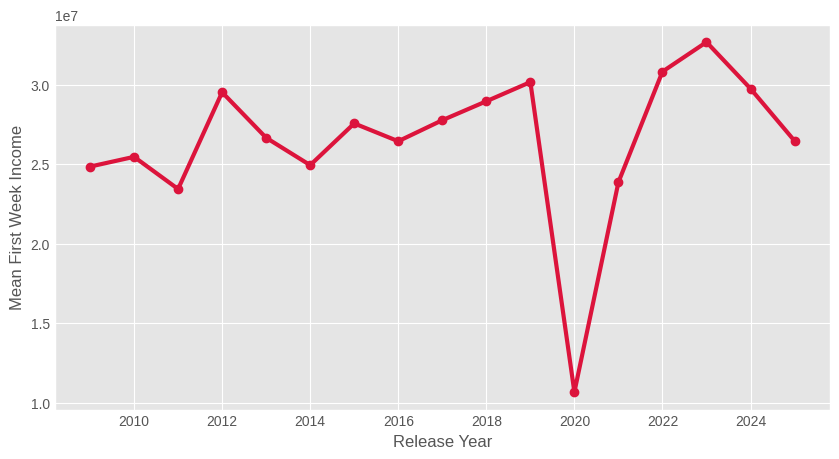

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_income.index, yearly_income.values, color='crimson', marker='o', linewidth=3, linestyle='-')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Mean First Week Income', fontsize=12)
plt.show()

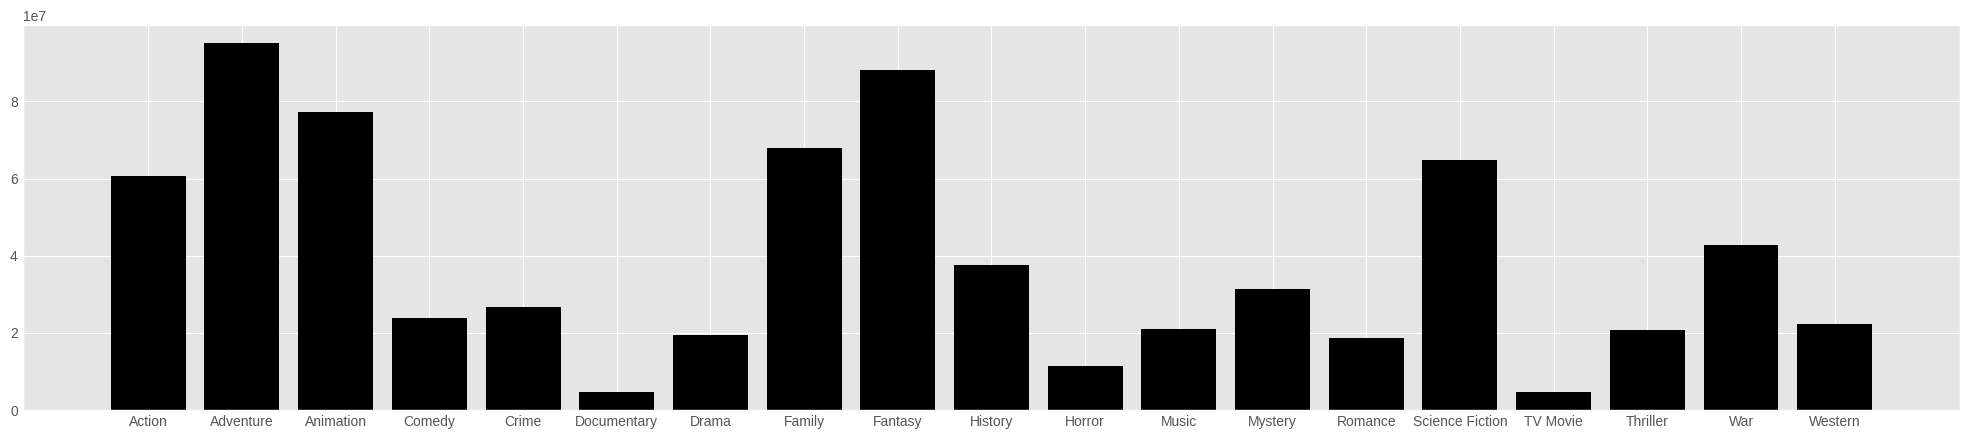

In [36]:
genre_budget = df.groupby('primary_genre')['budget'].mean()

plt.figure(figsize=(25, 5))
plt.bar(genre_budget.index, genre_budget.values, color='black')

plt.show()


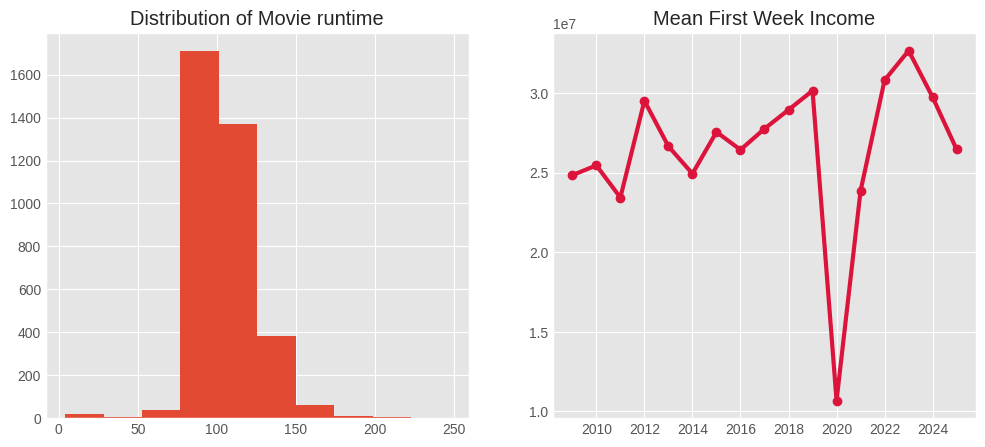

In [39]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['runtime'])
plt.title('Distribution of Movie runtime')

plt.subplot(1, 2, 2)
plt.plot(yearly_income.index, yearly_income.values, color='crimson', marker='o', linewidth=3, linestyle='-')
plt.title('Mean First Week Income')

plt.show()

In [48]:
df2 = df[df['budget'] > 40000000]

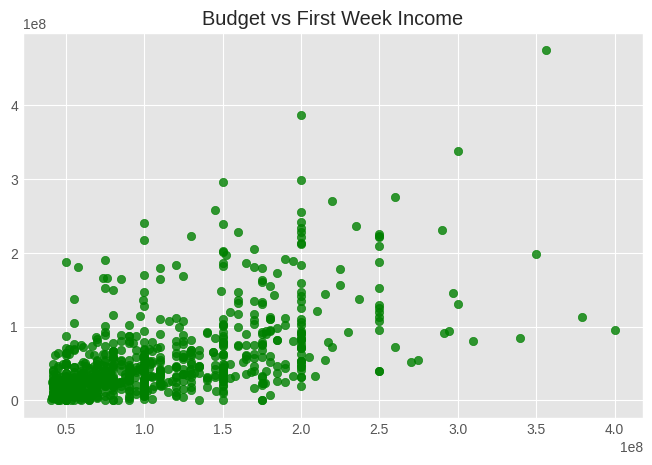

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(df2['budget'], df2['First_Week_Income'], color='green', alpha=0.8)

plt.title('Budget vs First Week Income')


plt.show()

In [50]:
rating_counts = df['mpaa_rating'].value_counts()

rating_counts

mpaa_rating
R        1641
PG-13    1052
PG        428
NR        422
G          43
NC-17       4
Name: count, dtype: int64

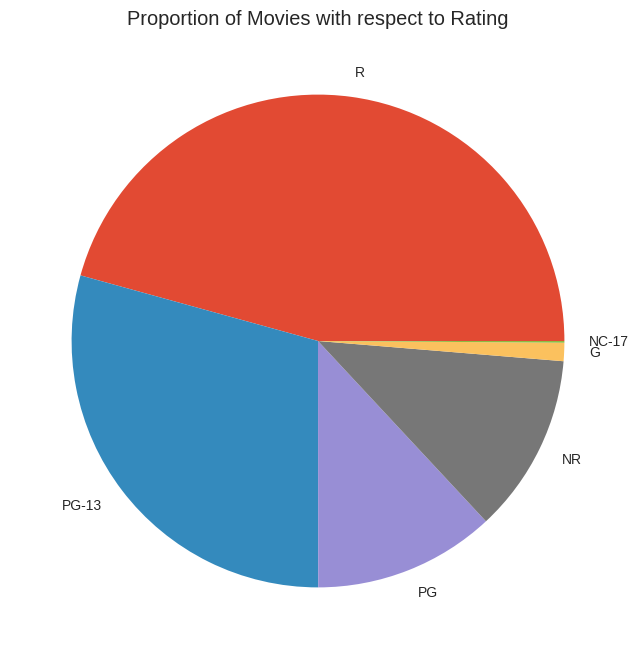

In [52]:
plt.figure(figsize=(8, 8))

plt.pie(rating_counts, labels=['R', 'PG-13', 'PG', 'NR', 'G', 'NC-17'])

plt.title('Proportion of Movies with respect to Rating')
plt.show()

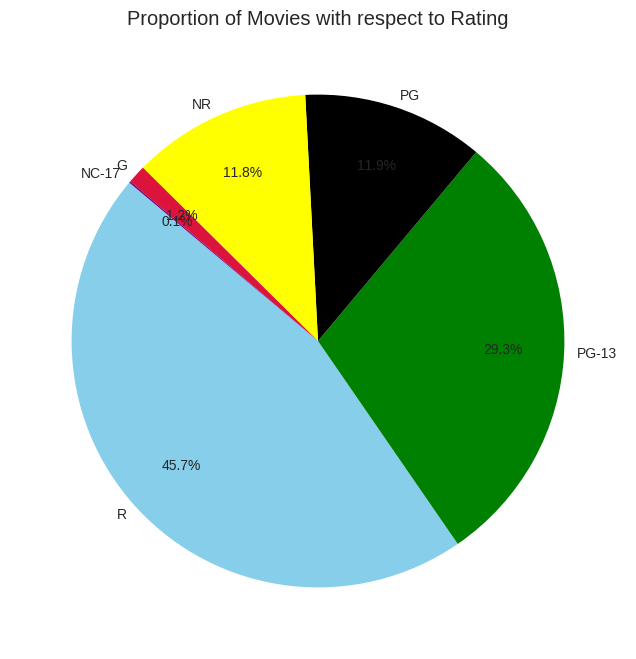

In [60]:
plt.figure(figsize=(8, 8))

plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', pctdistance=.75, startangle=140, labeldistance=1.05, colors=['skyblue', 'green', 'black', 'yellow', 'crimson', 'purple'])

plt.title('Proportion of Movies with respect to Rating')
plt.show()

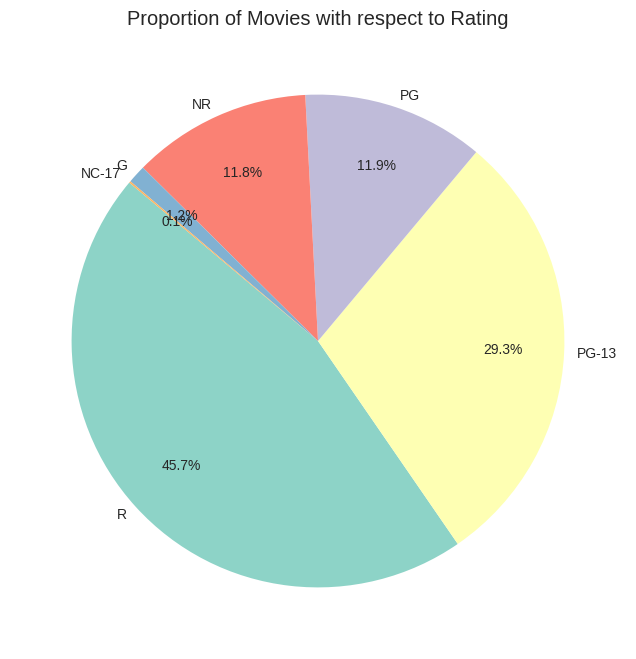

<Figure size 640x480 with 0 Axes>

In [68]:
plt.figure(figsize=(8, 8))

plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', pctdistance=.75, startangle=140, labeldistance=1.05)

plt.title('Proportion of Movies with respect to Rating')
plt.show()
plt.savefig('saved_graph.png', dpi=300, bbox_inches='tight')

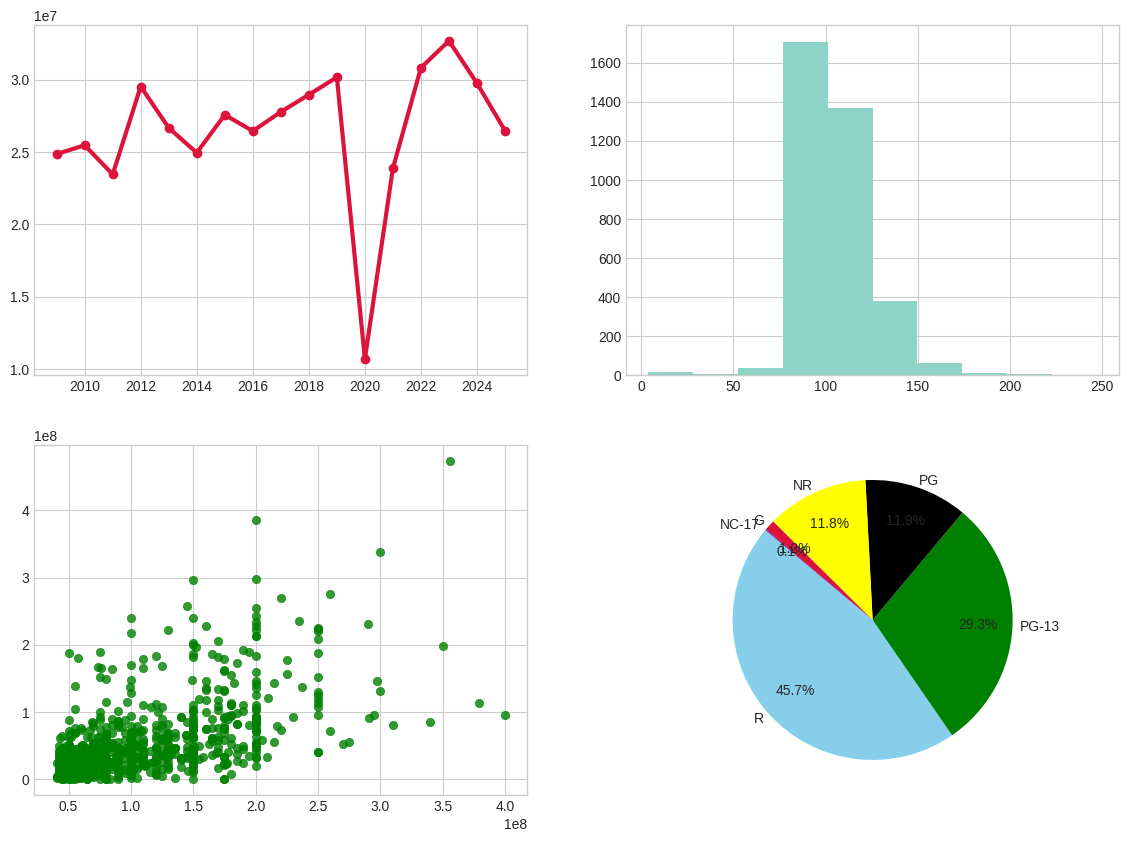

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(yearly_income.index, yearly_income.values, color='crimson', marker='o', linewidth=3, linestyle='-')
axes[0, 1].hist(df['runtime'])
axes[1, 0].scatter(df2['budget'], df2['First_Week_Income'], color='green', alpha=0.8)
axes[1, 1].pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', pctdistance=.75, startangle=140, labeldistance=1.05, colors=['skyblue', 'green', 'black', 'yellow', 'crimson', 'purple'])

plt.show()
fig.savefig('analysis.png')